<a href="https://colab.research.google.com/github/MetalHeadv3/Inzyrnieria-Big-Data/blob/main/Lab_1_zad_1_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd

df = pd.read_csv("zamowienia.csv", sep=';')
print(df.columns)

df.info(memory_usage='deep')

ram_default = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"RAM (domyślne typy): {ram_default:.2f} MB")



Index(['Kraj', 'Sprzedawca', 'Data zamowienia', 'idZamowienia', 'Utarg'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 799 entries, 0 to 798
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Kraj             799 non-null    object 
 1   Sprzedawca       799 non-null    object 
 2   Data zamowienia  799 non-null    object 
 3   idZamowienia     799 non-null    int64  
 4   Utarg            799 non-null    float64
dtypes: float64(1), int64(1), object(3)
memory usage: 146.9 KB
RAM (domyślne typy): 0.14 MB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 799 entries, 0 to 798
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Kraj             799 non-null    category
 1   Sprzedawca       799 non-null    category
 2   Data zamowienia  799 non-null    category
 3   idZamowienia     799 non-null    int16   
 4   Utarg            799 non-null    float32 
dtypes: category(3), float32(1), int16(1)
memory usage: 39.2 KB
RAM (po optymalizacji): 0.04 MB


/tmp/ipython-input-1755230521.py:10: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_opt = df_opt.apply(pd.to_numeric, errors='ignore', downcast='float')
/tmp/ipython-input-1755230521.py:10: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_opt = df_opt.apply(pd.to_numeric, errors='ignore', downcast='float')
/tmp/ipython-input-1755230521.py:11: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_opt = df_opt.apply(pd.to_numeric, errors='ignore', downcast='integer')


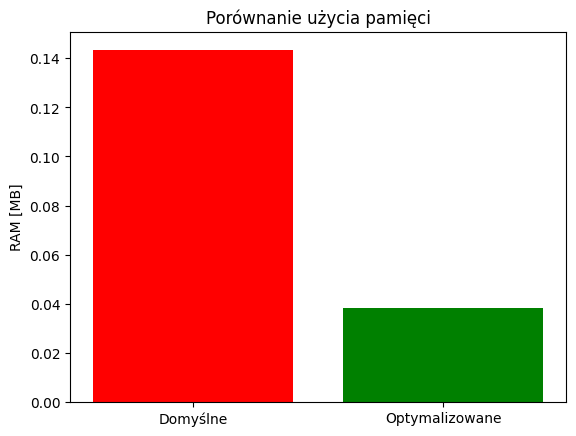

In [14]:
import matplotlib.pyplot as plt

df_opt = df.copy()

for col in df_opt.select_dtypes(include='object').columns:
    df_opt[col] = df_opt[col].astype('category')

df_opt = df_opt.apply(pd.to_numeric, errors='ignore', downcast='float')
df_opt = df_opt.apply(pd.to_numeric, errors='ignore', downcast='integer')

df_opt.info(memory_usage='deep')
ram_opt = df_opt.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"RAM (po optymalizacji): {ram_opt:.2f} MB")

plt.bar(['Domyślne', 'Optymalizowane'], [ram_default, ram_opt], color=['red', 'green'])
plt.ylabel('RAM [MB]')
plt.title('Porównanie użycia pamięci')
plt.show()


In [15]:
import time

def benchmark(df):
    start = time.time()
    df.groupby('Kraj')['Utarg'].mean()
    df[df['Utarg'] > 1000]
    df.sort_values(by='Data zamowienia', ascending=False)
    return time.time() - start

czas_default = benchmark(df)
czas_opt = benchmark(df_opt)

print(f"Czas operacji (domyślne typy): {czas_default:.4f} s")
print(f"Czas operacji (optymalizowane typy): {czas_opt:.4f} s")



Czas operacji (domyślne typy): 0.0039 s
Czas operacji (optymalizowane typy): 0.0084 s


/tmp/ipython-input-455044000.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Kraj')['Utarg'].mean()


In [16]:
df_opt.to_csv("zamowienia_optymalne.csv", index=False)
df_opt.to_parquet("zamowienia_optymalne.parquet")



In [18]:
import multiprocessing

start = time.time()
df_full = pd.read_csv("zamowienia_optymalne.csv")
czas_full = time.time() - start

start = time.time()
chunks = pd.read_csv("zamowienia_optymalne.csv", chunksize=10000)
df_chunks = pd.concat(chunks)
czas_chunks = time.time() - start

def read_chunk(path):
    return pd.read_csv(path)

paths = ["zamowienia_part1.csv", "zamowienia_part2.csv"]

ilosc_rdzeni = multiprocessing.cpu_count()
print(f"Liczba dostępnych rdzeni CPU: {ilosc_rdzeni}")

for n_proc in [ilosc_rdzeni - 2, (ilosc_rdzeni - 2) * 2]:
    if n_proc < 1:
        print(f"Pominięto konfigurację z {n_proc} procesami (za mało rdzeni).")
        continue

    start = time.time()
    with multiprocessing.Pool(n_proc) as pool:
        dfs = pool.map(read_chunk, paths)
    df_multi = pd.concat(dfs)
    czas_multi = time.time() - start
    print(f"Czas multiprocessing ({n_proc} procesów): {czas_multi:.4f} s")

print(f"\nCzas pełnego wczytania: {czas_full:.4f} s")
print(f"Czas z chunksize: {czas_chunks:.4f} s")



Liczba dostępnych rdzeni CPU: 2
Pominięto konfigurację z 0 procesami (za mało rdzeni).
Pominięto konfigurację z 0 procesami (za mało rdzeni).

Czas pełnego wczytania: 0.0054 s
Czas z chunksize: 0.0032 s
